In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [5]:
# 1. Загрузка данных

FILE_PATH = "Данные_для_курсовои_Классическое_МО.xlsx"

df = pd.read_excel(FILE_PATH)

print("Размерность датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

print("\nСписок столбцов:")
print(df.columns.tolist())


Размерность датасета: (1001, 214)

Первые 5 строк:


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0



Список столбцов:
['Unnamed: 0', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_

In [6]:
# 2. Базовая информация

print("\nИнформация о данных:")
print(df.info())

print("\nКоличество пропусков по столбцам:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nКоличество дубликатов:", df.duplicated().sum())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB
None

Количество пропусков по столбцам:


MinAbsPartialCharge    3
BCUT2D_LOGPHI          3
BCUT2D_MWHI            3
MaxAbsPartialCharge    3
MinPartialCharge       3
MaxPartialCharge       3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64


Количество дубликатов: 0


In [7]:
# 3. Переименование и разделение

TARGETS = ["IC50, mM", "CC50, mM", "SI"]
ID_COL = "Unnamed: 0"

df_work = df.copy()

if ID_COL in df_work.columns:
    df_work = df_work.drop(columns=[ID_COL])

feature_cols = [c for c in df_work.columns if c not in TARGETS]

print("\nКоличество признаков:", len(feature_cols))
print("Целевые переменные:", TARGETS)


Количество признаков: 210
Целевые переменные: ['IC50, mM', 'CC50, mM', 'SI']


In [8]:
# 4. Статистика по целям

print("\nОписательная статистика целевых переменных:")
display(df_work[TARGETS].describe().T)


Описательная статистика целевых переменных:


,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000


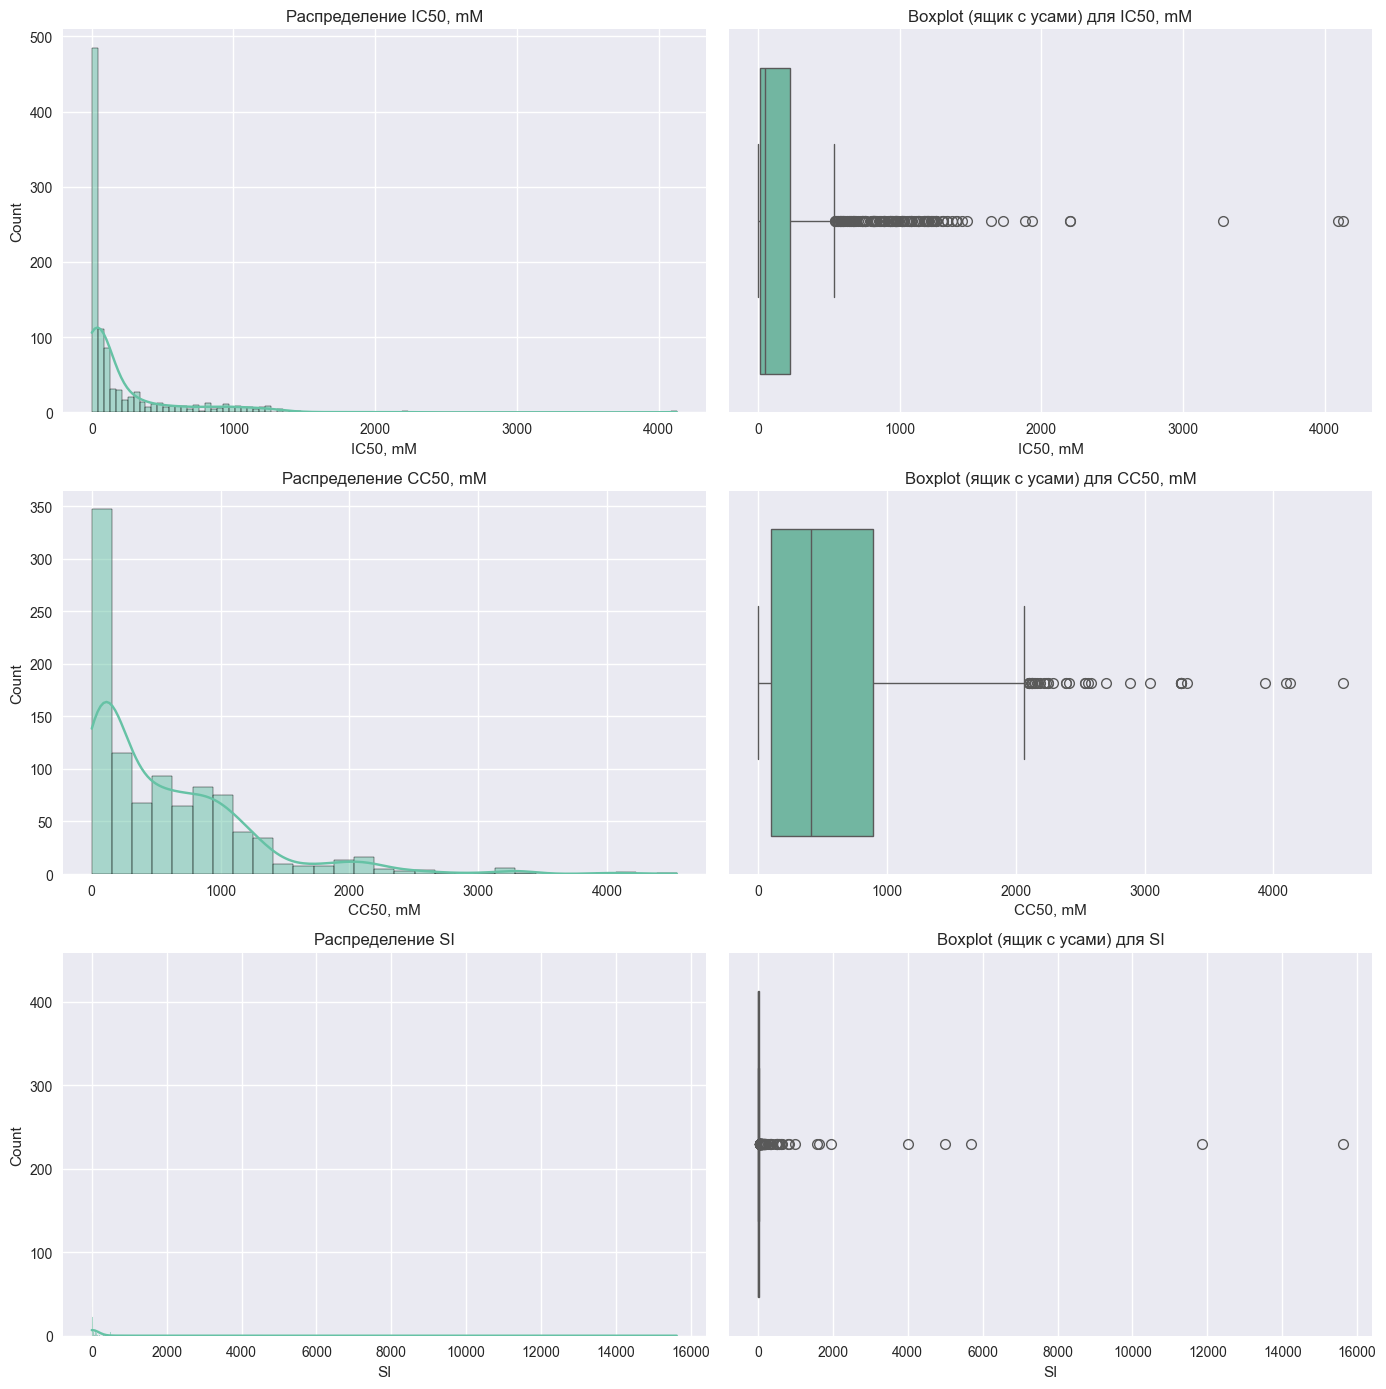

In [9]:
# 5. Распределения целевых переменных

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, target in enumerate(TARGETS):
    sns.histplot(df_work[target], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Распределение {target}")

    sns.boxplot(x=df_work[target], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot (ящик с усами) для {target}")

plt.tight_layout()
plt.show()

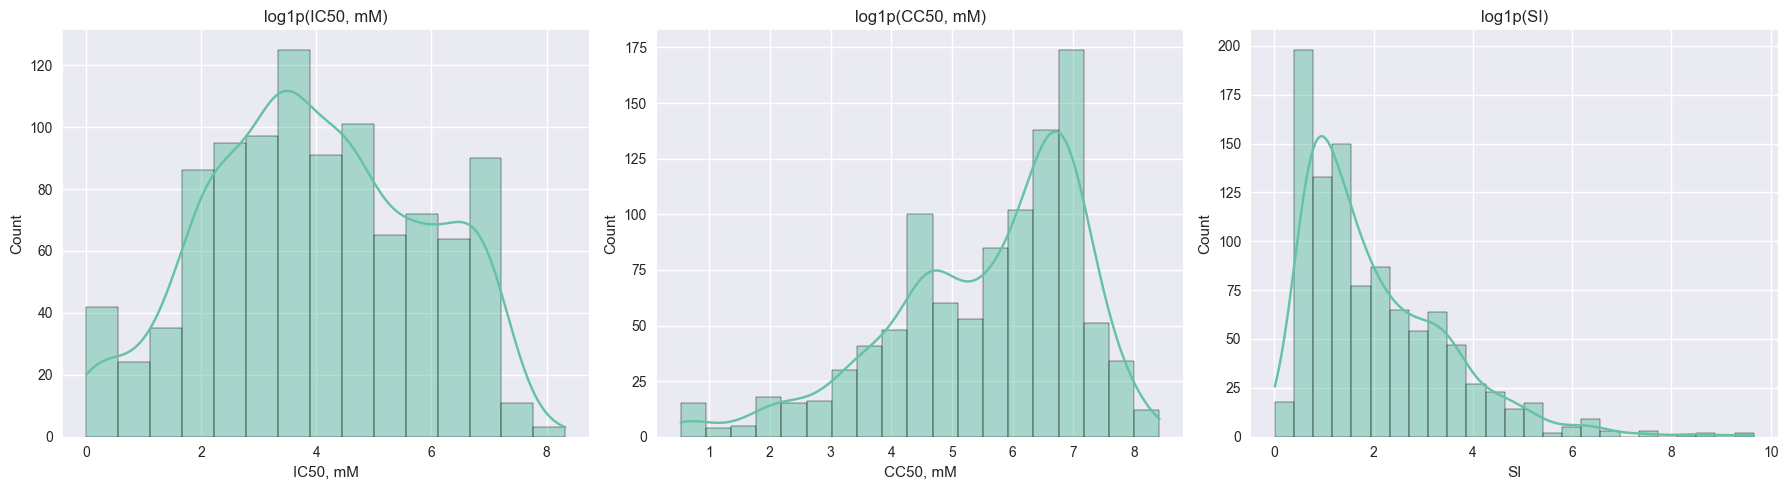

In [10]:
# 6. Логарифмические распределения целей

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(TARGETS):
    sns.histplot(np.log1p(df_work[target]), kde=True, ax=axes[i])
    axes[i].set_title(f"log1p({target})")

plt.tight_layout()
plt.show()



Вывод: целевые переменные сильно скошены вправо, поэтому для регрессии целесообразно использовать log1p-преобразование.

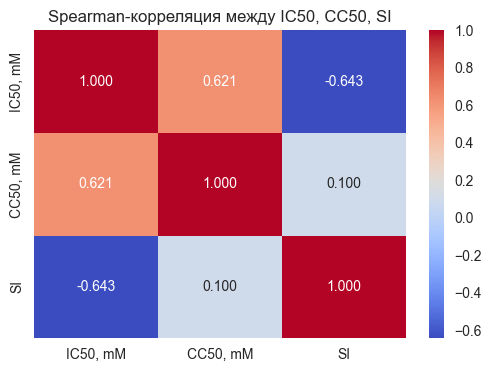

In [11]:
# 7. Корреляции между целями

plt.figure(figsize=(6, 4))
corr_targets = df_work[TARGETS].corr(method="spearman")
sns.heatmap(corr_targets, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Spearman-корреляция между IC50, CC50, SI")
plt.show()

In [12]:
# 8. Анализ пропусков в признаках

X = df_work[feature_cols].copy()

missing_features = X.isna().sum().sort_values(ascending=False)
print("\nПропуски в признаках:")
display(missing_features[missing_features > 0])


Пропуски в признаках:


BCUT2D_MWHI            3
MaxPartialCharge       3
BCUT2D_MWLOW           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
MinAbsPartialCharge    3
MaxAbsPartialCharge    3
MinPartialCharge       3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
dtype: int64

In [13]:
# 9. Удаление константных признаков (для анализа)

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

selector = VarianceThreshold(threshold=0.0)
X_non_const = selector.fit_transform(X_imputed)
selected_cols = X_imputed.columns[selector.get_support()]

removed_const = [col for col in X_imputed.columns if col not in selected_cols]

print(f"\nКоличество признаков до удаления константных: {X_imputed.shape[1]}")
print(f"Количество признаков после удаления константных: {len(selected_cols)}")
print(f"Удалено константных признаков: {len(removed_const)}")

if len(removed_const) > 0:
    print("\nПримеры удалённых константных признаков:")
    print(removed_const[:20])


Количество признаков до удаления константных: 210
Количество признаков после удаления константных: 192
Удалено константных признаков: 18

Примеры удалённых константных признаков:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


In [14]:
# 10. Корреляция признаков с целями

# Чтобы не строить огромную матрицу, посчитаем Spearman корреляцию каждого признака с целями
corr_summary = []

for target in TARGETS:
    tmp = X_imputed.apply(lambda col: col.corr(df_work[target], method="spearman"))
    tmp = tmp.abs().sort_values(ascending=False)
    top_corr = tmp.head(15)
    corr_summary.append((target, top_corr))

for target, top_corr in corr_summary:
    print(f"\nТоп-15 признаков по |Spearman correlation| с {target}:")
    display(top_corr.to_frame(name=f"|corr| with {target}"))


Топ-15 признаков по |Spearman correlation| с IC50, mM:


,"|corr| with IC50, mM"
NumSaturatedHeterocycles,0.277862
SlogP_VSA5,0.270496
VSA_EState4,0.259461
NumAliphaticCarbocycles,0.245072
fr_NH2,0.242980
VSA_EState8,0.238564
PEOE_VSA7,0.228182
NumAliphaticHeterocycles,0.223751
EState_VSA8,0.218501
SMR_VSA5,0.212524



Топ-15 признаков по |Spearman correlation| с CC50, mM:


,"|corr| with CC50, mM"
Kappa2,0.302849
Kappa3,0.299059
Kappa1,0.293032
MolMR,0.283132
Chi1v,0.279799
Chi0v,0.278131
NumValenceElectrons,0.277745
Chi0,0.277594
Chi1n,0.276383
LabuteASA,0.276046



Топ-15 признаков по |Spearman correlation| с SI:


,|corr| with SI
fr_Imine,0.216453
MaxAbsEStateIndex,0.200892
MaxEStateIndex,0.200892
NumSaturatedCarbocycles,0.200845
MinEStateIndex,0.195659
FractionCSP3,0.191442
SMR_VSA4,0.189550
NumAliphaticCarbocycles,0.188778
NumSaturatedHeterocycles,0.183711
VSA_EState8,0.182660


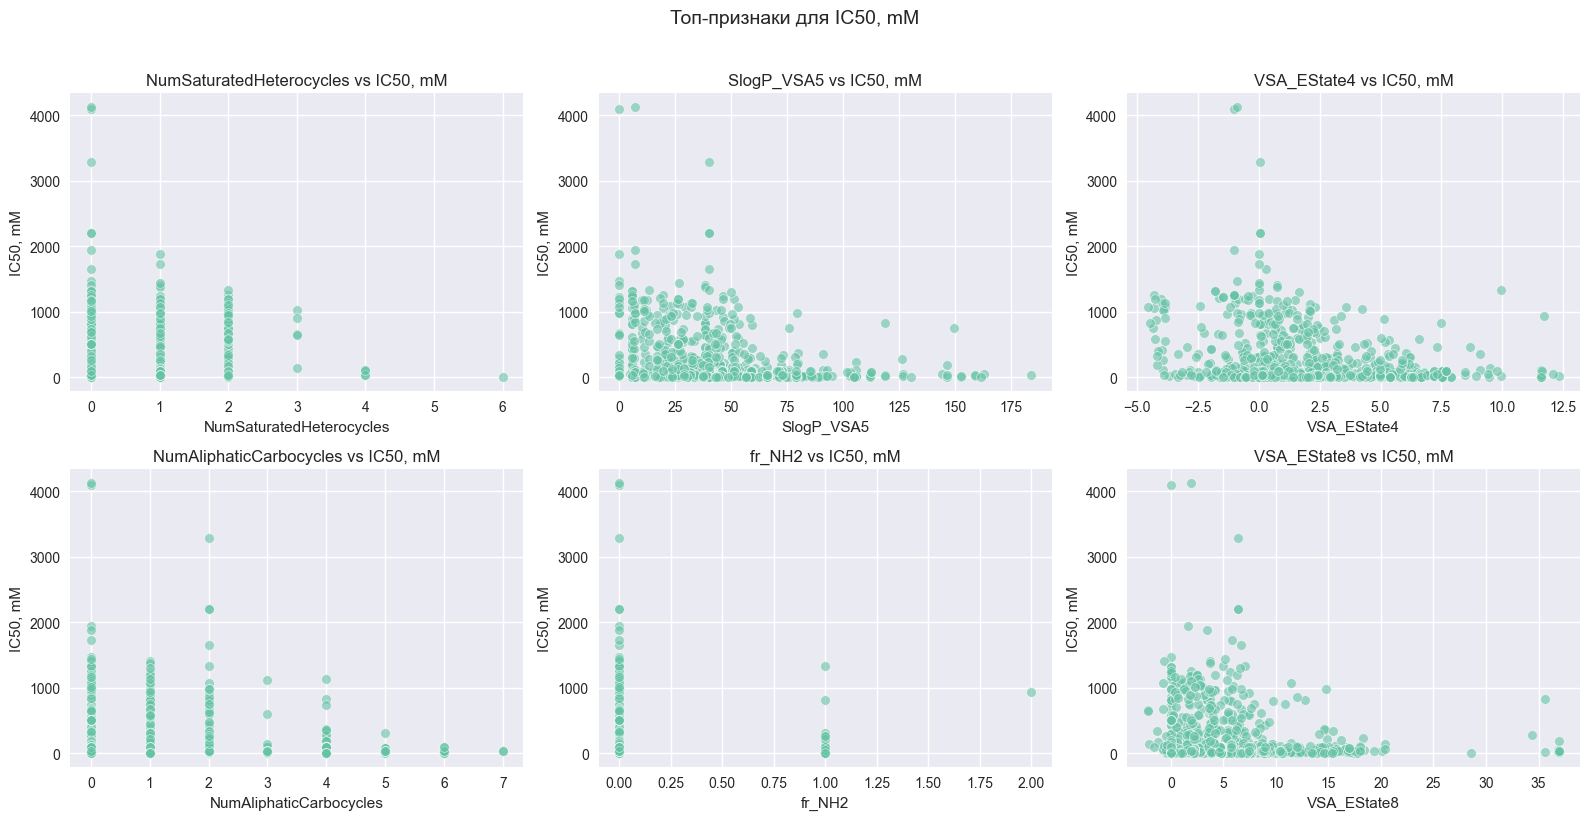

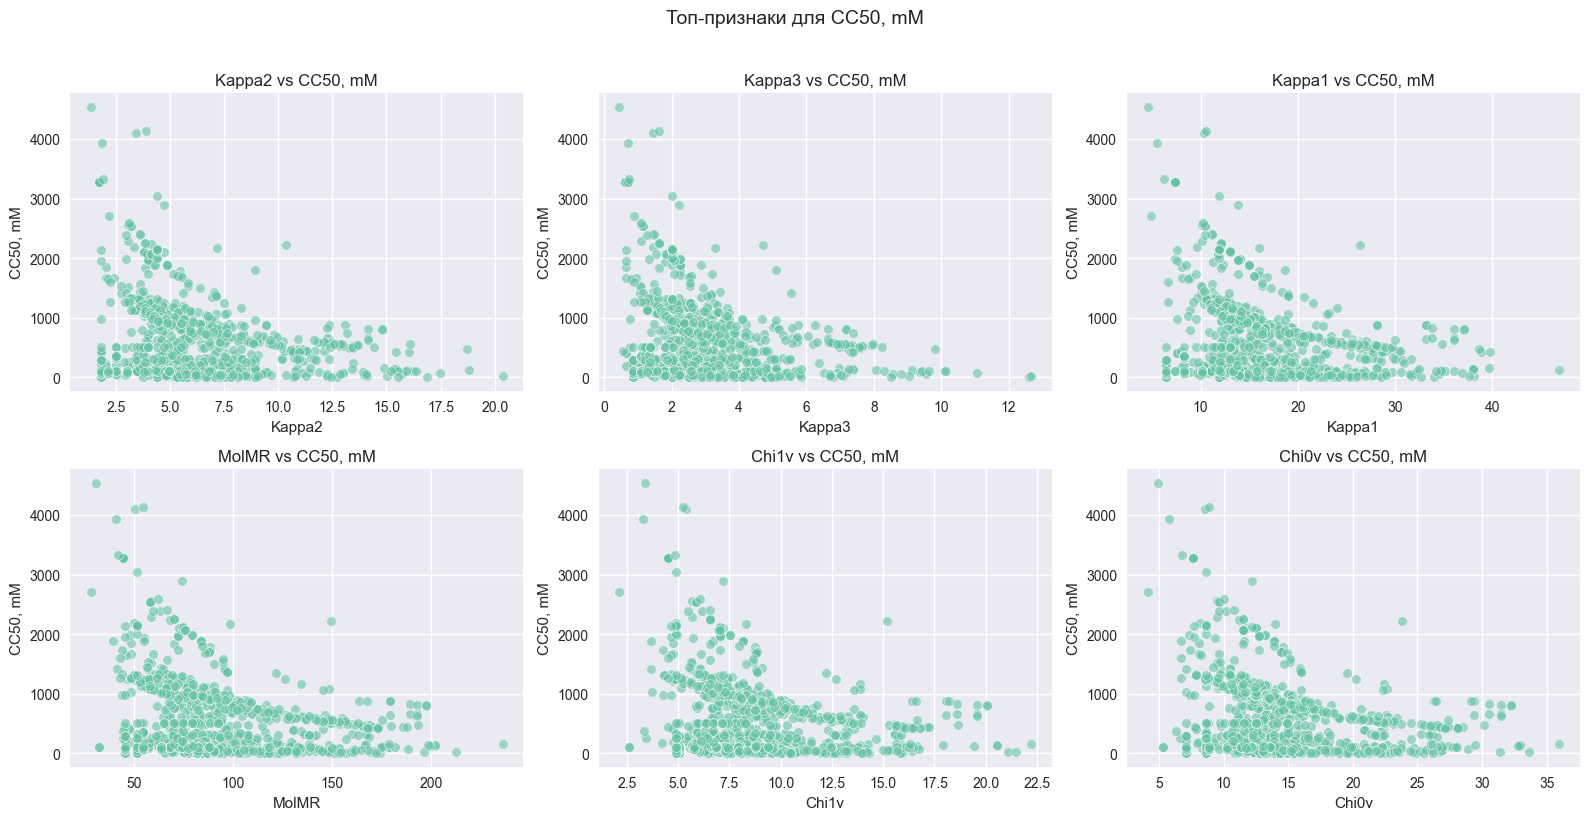

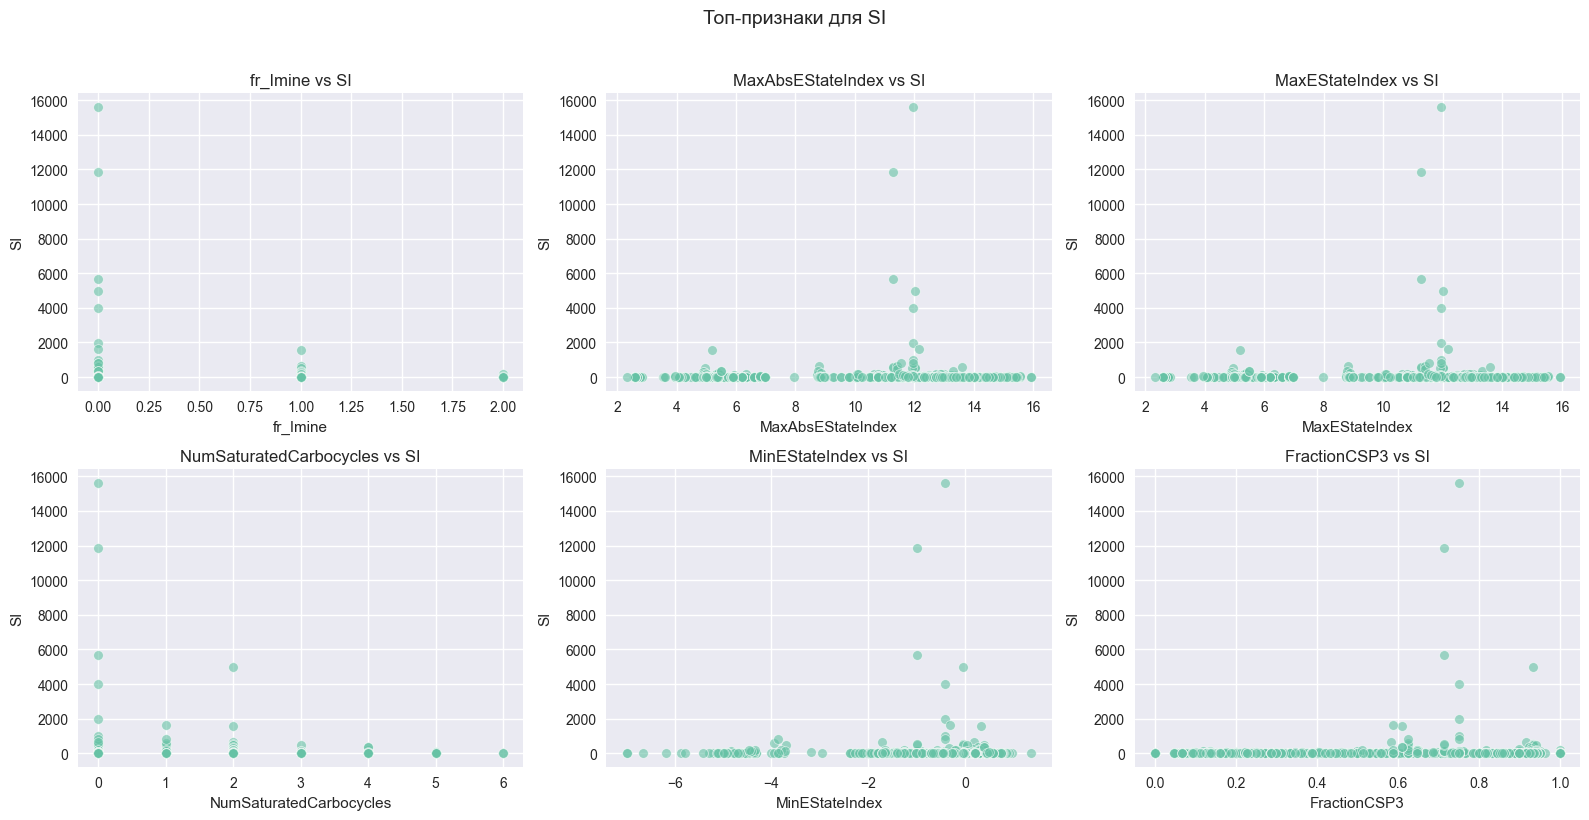

In [15]:
# 11. Визуализация топ признаков для каждой цели

for target, top_corr in corr_summary:
    top_features = top_corr.index[:6].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        sns.scatterplot(x=X_imputed[feat], y=df_work[target], ax=axes[i], alpha=0.6)
        axes[i].set_title(f"{feat} vs {target}")

    plt.suptitle(f"Топ-признаки для {target}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [16]:
# 12. Медианы для классификационных задач

ic50_median = df_work["IC50, mM"].median()
cc50_median = df_work["CC50, mM"].median()
si_median = df_work["SI"].median()

print("\nМедианы:")
print(f"IC50 median = {ic50_median:.6f}")
print(f"CC50 median = {cc50_median:.6f}")
print(f"SI median = {si_median:.6f}")


Медианы:
IC50 median = 46.585183
CC50 median = 411.039342
SI median = 3.846154


In [17]:
# 13. Баланс классов для будущих задач классификации

class_tasks = {
    "IC50 > median": (df_work["IC50, mM"] > ic50_median).astype(int),
    "CC50 > median": (df_work["CC50, mM"] > cc50_median).astype(int),
    "SI > median": (df_work["SI"] > si_median).astype(int),
    "SI > 8": (df_work["SI"] > 8).astype(int),
}

balance_df = pd.DataFrame({
    task: y.value_counts().sort_index()
    for task, y in class_tasks.items()
}).T

balance_df.columns = ["Class 0", "Class 1"]
balance_df["Positive rate"] = balance_df["Class 1"] / (balance_df["Class 0"] + balance_df["Class 1"])

print("\nБаланс классов:")
display(balance_df)


Баланс классов:


,Class 0,Class 1,Positive rate
IC50 > median,501,500,0.499500
CC50 > median,502,499,0.498501
SI > median,501,500,0.499500
SI > 8,644,357,0.356643


КЛЮЧЕВЫЕ ВЫВОДЫ EDA:
1. Датасет содержит 1001 наблюдение и более 200 дескрипторов молекул.
2. Присутствует небольшое количество пропусков в части числовых признаков; их можно корректно заполнить медианой.
3. Целевые переменные IC50, CC50 и особенно SI имеют выраженную правостороннюю асимметрию и выбросы.
4. Для регрессионных задач оправдано использование log1p-преобразования целевой переменной.
5. В наборе присутствуют константные/слабополезные признаки — их необходимо удалять.
6. Для задач классификации по медиане классы близки к сбалансированным, что удобно для обучения.
7. Для задачи SI > 8 баланс может быть менее равномерным, поэтому важно контролировать ROC-AUC, F1-score и balanced accuracy.
8. Наиболее перспективными моделями ожидаемо являются ансамбли деревьев и бустинг, так как они хорошо работают на нелинейных зависимостях и химических дескрипторах.